<p style="margin: 5px 0 0 0; color: #666;"><em>Desarrollado con Claude - Anthropic</em></p>

# 18. Evaluacion de Modelos y Decisiones de Negocio

Ruta de Analista de Datos Basico con Python

---

Objetivo: convertir metricas tecnicas en decisiones accionables para negocio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, mean_absolute_error, root_mean_squared_error, r2_score
)

sns.set_theme(style='whitegrid')
np.random.seed(42)

print('Notebook 18 listo: Evaluacion y decisiones de negocio')

Notebook 18 listo: Evaluacion y decisiones de negocio


## Introduccion

### Que es?
Evaluar modelos significa medir su desempeno tecnico y, al mismo tiempo, interpretar su impacto operativo y economico.

Una metrica aislada (por ejemplo accuracy) no siempre representa el valor real para negocio.

### Para que sirve?
Permite responder preguntas clave:
- que tipo de error es mas costoso?
- que umbral de decision conviene usar?
- que accion deberia tomar el equipo con base en el modelo?

En otras palabras, conecta ciencia de datos con toma de decisiones.

### Como se usa?
En este notebook trabajaremos tres niveles:
1. Metricas de clasificacion y matriz de confusion
2. Ajuste de umbral segun costos de negocio
3. Traduccion de resultados a recomendacion ejecutiva

## 1. Clasificacion: Metricas y Matriz de Confusion

### Que es?
En clasificacion binaria comparamos predicciones vs realidad para obtener:
- accuracy: porcentaje total de aciertos
- precision: calidad de los positivos predichos
- recall: cobertura de positivos reales
- F1: equilibrio entre precision y recall
- ROC AUC: capacidad de separacion global por probabilidades

### Para que sirve?
Cada metrica responde una pregunta distinta.

Ejemplo en churn:
- recall bajo implica que se escapan clientes en riesgo
- precision baja implica acciones de retencion sobre clientes que no se irian

Por eso no basta con mirar una sola metrica.

### Como se usa?
Entrenamos un modelo, obtenemos probabilidades y evaluamos con umbral inicial 0.50 para establecer punto de partida.

In [2]:
# ------------------------------------------------------
# 1) Simulamos un caso de clasificacion (churn)
# ------------------------------------------------------
# La variable objetivo sera churn (1=abandona, 0=permanece).
# Generamos features con relaciones plausibles de negocio.
n = 5000
df = pd.DataFrame({
    'antiguedad': np.random.randint(1, 61, n),
    'uso': np.random.gamma(2, 7, n),
    'tickets': np.random.poisson(2.1, n),
    'plan': np.random.choice(['basico', 'plus', 'premium'], n, p=[0.55, 0.30, 0.15]),
    'canal': np.random.choice(['app', 'web', 'telefono'], n, p=[0.60, 0.30, 0.10])
})

# Funcion latente de riesgo de churn.
score = (
    -2.0
    - 0.03 * df['antiguedad']
    - 0.04 * df['uso']
    + 0.42 * (df['tickets'] >= 3).astype(int)
    + 0.30 * (df['plan'] == 'basico').astype(int)
    + 0.22 * (df['canal'] == 'telefono').astype(int)
    + np.random.normal(0, 0.55, n)
)

proba = 1 / (1 + np.exp(-score))
df['churn'] = np.random.binomial(1, proba)

# Separacion de variables
X = df.drop(columns=['churn'])
y = df['churn']

# Split estratificado para mantener proporcion de churn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

num = X.select_dtypes(include=['number']).columns.tolist()
cat = X.select_dtypes(exclude=['number']).columns.tolist()

# Pipeline con preprocesamiento + modelo
pipe = Pipeline(steps=[
    ('prep', ColumnTransformer([
        ('num', StandardScaler(), num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat)
    ])),
    ('clf', LogisticRegression(max_iter=1000))
])

pipe.fit(X_train, y_train)

# Probabilidades para analizar umbrales
proba_test = pipe.predict_proba(X_test)[:, 1]

# Punto de partida clasico: umbral 0.50
pred_05 = (proba_test >= 0.50).astype(int)

metricas = pd.Series({
    'accuracy': accuracy_score(y_test, pred_05),
    'precision': precision_score(y_test, pred_05, zero_division=0),
    'recall': recall_score(y_test, pred_05, zero_division=0),
    'f1': f1_score(y_test, pred_05, zero_division=0),
    'roc_auc': roc_auc_score(y_test, proba_test)
}).round(3)

print('Tasa de churn:', round(y.mean(), 3))
metricas

Tasa de churn: 0.054


accuracy     0.946
precision    0.000
recall       0.000
f1           0.000
roc_auc      0.638
dtype: float64

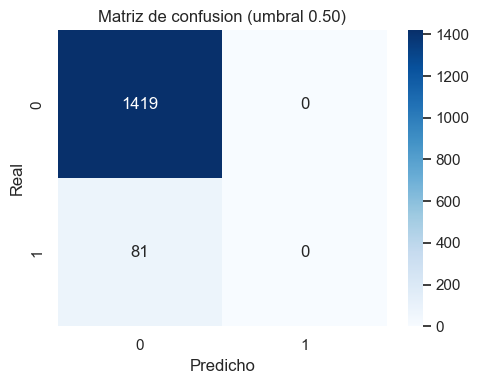

In [3]:
cm = confusion_matrix(y_test, pred_05)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusion (umbral 0.50)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

## 2. Umbral de Decision y Costo de Negocio

### Que es?
El umbral convierte probabilidades en decisiones binarias.

Si probabilidad >= umbral => accion positiva
Si probabilidad < umbral => accion negativa

### Para que sirve?
Cambiar umbral altera el balance entre falsos positivos y falsos negativos.
Como ambos errores no cuestan igual, el mejor umbral depende del contexto de negocio.

### Como se usa?
1. Definimos una funcion de costo
2. Probamos varios umbrales
3. Elegimos el de menor costo total esperado

Esta es una de las practicas mas utiles para pasar de modelado tecnico a impacto economico.

In [4]:
# ------------------------------------------------------
# 2) Analisis de umbral con funcion de costo
# ------------------------------------------------------
# Supuesto de negocio:
# - Falso negativo (no detectar churn): costo alto
# - Falso positivo (accion innecesaria): costo bajo
costo_fn = 220
costo_fp = 25

def costo_total(y_true, y_pred, costo_fn=220, costo_fp=25):
    cm = confusion_matrix(y_true, y_pred)
    fp = cm[0, 1]
    fn = cm[1, 0]
    return fp * costo_fp + fn * costo_fn

umbrales = np.arange(0.20, 0.81, 0.05)
registros = []

for t in umbrales:
    pred_t = (proba_test >= t).astype(int)
    registros.append({
        'umbral': round(t, 2),
        'precision': precision_score(y_test, pred_t, zero_division=0),
        'recall': recall_score(y_test, pred_t, zero_division=0),
        'f1': f1_score(y_test, pred_t, zero_division=0),
        'costo_total_usd': costo_total(y_test, pred_t, costo_fn, costo_fp)
    })

# Tabla comparativa para elegir la estrategia mas rentable.
df_umb = pd.DataFrame(registros)
df_umb.sort_values('costo_total_usd').head()

,umbral,precision,recall,f1,costo_total_usd
0,0.20,0.5,0.012346,0.024096,17625
1,0.25,0.0,0.000000,0.000000,17820
2,0.30,0.0,0.000000,0.000000,17820
3,0.35,0.0,0.000000,0.000000,17820
4,0.40,0.0,0.000000,0.000000,17820


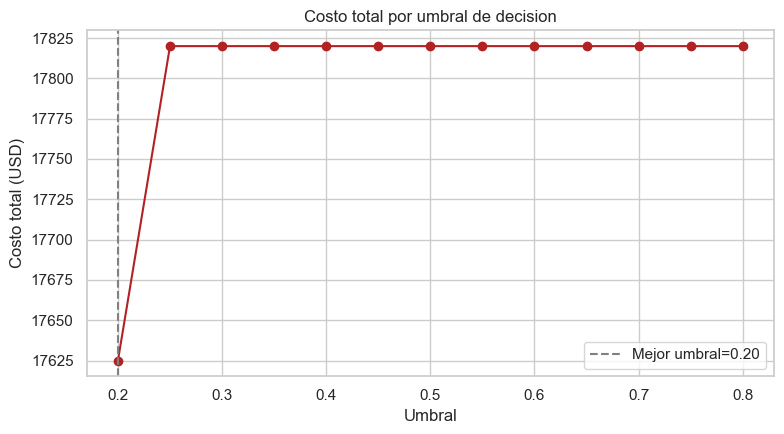

Mejor umbral: 0.2
Costo minimo estimado (USD): 17625


In [5]:
best = df_umb.sort_values('costo_total_usd').iloc[0]
best_t = float(best['umbral'])

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(df_umb['umbral'], df_umb['costo_total_usd'], marker='o', color='firebrick')
ax1.axvline(best_t, color='gray', linestyle='--', label=f'Mejor umbral={best_t:.2f}')
ax1.set_title('Costo total por umbral de decision')
ax1.set_xlabel('Umbral')
ax1.set_ylabel('Costo total (USD)')
ax1.legend()
plt.tight_layout()
plt.show()

print('Mejor umbral:', best_t)
print('Costo minimo estimado (USD):', int(best['costo_total_usd']))

## 3. Regresion: Error Tecnico vs Tolerancia de Negocio

### Que es?
En regresion medimos distancia entre valor real y predicho.

Metricas frecuentes:
- MAE: error promedio en unidades del problema
- RMSE: penaliza errores grandes
- R2: porcentaje de variabilidad explicada

### Para que sirve?
Negocio normalmente trabaja con "tolerancias" aceptables.
Por ejemplo: que porcentaje de predicciones cae dentro de +/- 200 unidades.

Combinar metrica tecnica con tolerancia operativa facilita decisiones realistas.

### Como se usa?
Simulamos demanda real/predicha y medimos tanto error estadistico como cumplimiento de tolerancia de negocio.

In [6]:
n_d = 900
demanda_real = np.random.normal(1800, 320, n_d).clip(500, None)
error_modelo = np.random.normal(0, 180, n_d)
demanda_pred = demanda_real + error_modelo

mae = mean_absolute_error(demanda_real, demanda_pred)
rmse = root_mean_squared_error(demanda_real, demanda_pred)
r2 = r2_score(demanda_real, demanda_pred)

# KPI de negocio: porcentaje de predicciones con error absoluto <= 200 unidades
error_abs = np.abs(demanda_real - demanda_pred)
pct_tolerancia = (error_abs <= 200).mean()

res_reg = pd.Series({
    'MAE': round(mae, 2),
    'RMSE': round(rmse, 2),
    'R2': round(r2, 3),
    '% dentro tolerancia (<=200)': round(pct_tolerancia * 100, 2)
})

res_reg

MAE                            145.270
RMSE                           180.420
R2                               0.668
% dentro tolerancia (<=200)     72.890
dtype: float64

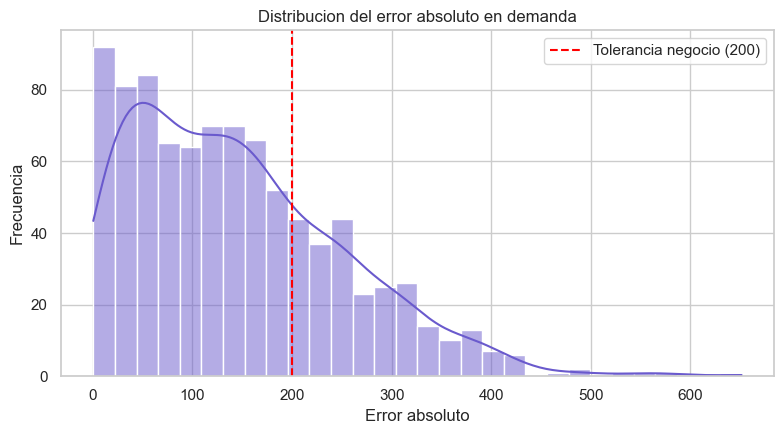

In [7]:
plt.figure(figsize=(8, 4.5))
sns.histplot(error_abs, bins=30, kde=True, color='slateblue')
plt.axvline(200, color='red', linestyle='--', label='Tolerancia negocio (200)')
plt.title('Distribucion del error absoluto en demanda')
plt.xlabel('Error absoluto')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Traduccion a Recomendacion Ejecutiva

### Que es?
Es la etapa donde transformas resultados tecnicos en un mensaje claro para decision makers.

### Para que sirve?
Porque los stakeholders no necesitan ver todo el detalle matematico, sino:
- que decision tomar
- por que esa decision es razonable
- cual es el impacto esperado

### Como se usa?
Armaremos un resumen corto con KPIs accionables:
- umbral recomendado
- costo estimado
- casos detectados/no detectados
- precision y recall de la estrategia elegida

Este formato es ideal para comites, jefaturas o presentaciones ejecutivas.

In [8]:
pred_best = (proba_test >= best_t).astype(int)
cm_best = confusion_matrix(y_test, pred_best)
fn = cm_best[1, 0]
tp = cm_best[1, 1]

resumen_ejecutivo = pd.DataFrame({
    'KPI': [
        'Umbral recomendado',
        'Costo total estimado',
        'Clientes churn detectados (TP)',
        'Churn no detectado (FN)',
        'Precision',
        'Recall'
    ],
    'Valor': [
        f'{best_t:.2f}',
        f'USD {int(costo_total(y_test, pred_best, costo_fn, costo_fp)):,}',
        int(tp),
        int(fn),
        round(precision_score(y_test, pred_best, zero_division=0), 3),
        round(recall_score(y_test, pred_best, zero_division=0), 3)
    ]
})

resumen_ejecutivo

,KPI,Valor
0,Umbral recomendado,0.20
1,Costo total estimado,"USD 17,625"
2,Clientes churn detectados (TP),1
3,Churn no detectado (FN),80
4,Precision,0.5
5,Recall,0.012


## 5. Ejercicio Practico Integrador

### Que es?
Una simulacion de decision ejecutiva donde cambian las reglas de costo del negocio.

### Para que sirve?
Te entrena para adaptar el modelo a distintos contextos:
- crisis de retencion (FN mas costoso)
- presupuesto limitado (FP mas costoso)

### Instrucciones
1. Cambia costos a: FN=300 y FP=15
2. Recalcula el mejor umbral
3. Compara con el umbral actual
4. Escribe una recomendacion ejecutiva en 5 lineas

Sugerencia: explica explicitamente el trade-off entre recall y costo total.

In [9]:
costo_fn_2 = 300
costo_fp_2 = 15

registros_2 = []
for t in umbrales:
    pred_t = (proba_test >= t).astype(int)
    registros_2.append({
        'umbral': round(t, 2),
        'costo_total_usd': costo_total(y_test, pred_t, costo_fn_2, costo_fp_2)
    })

df_umb_2 = pd.DataFrame(registros_2)
best2 = df_umb_2.sort_values('costo_total_usd').iloc[0]

print('Mejor umbral escenario original:', best_t)
print('Mejor umbral escenario nuevo:   ', float(best2['umbral']))
print('Costo minimo nuevo (USD):', int(best2['costo_total_usd']))

Mejor umbral escenario original: 0.2
Mejor umbral escenario nuevo:    0.2
Costo minimo nuevo (USD): 24015


## Cierre

En este notebook aprendiste:
- Elegir metricas segun objetivo de negocio
- Ajustar umbrales con funcion de costo
- Complementar evaluacion tecnica con KPIs ejecutivos

Con esto tienes la base completa para entrar al notebook 15 de proyectos aplicados con un criterio analitico mas profesional.